In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [3]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [4]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

In [5]:
embeddings["Commodore_64"]

array([-4.78663901e-03,  5.28012514e-02, -1.18841883e-02, -6.55887872e-02,
       -6.32080734e-02, -2.92002633e-02, -9.49030183e-03,  3.76941487e-02,
       -8.40732977e-02,  2.45147794e-02,  4.13881466e-02, -3.17692421e-02,
       -1.28062926e-02, -6.77377284e-02, -4.51803673e-03,  5.71266050e-03,
       -8.04296657e-02, -3.13056409e-02,  3.76184694e-02,  2.40874756e-02,
       -4.56155799e-02,  1.89303849e-02, -1.17414705e-01,  2.43022200e-02,
       -1.69093087e-02,  4.57564779e-02,  4.29776264e-03,  9.08945054e-02,
        5.74714355e-02, -9.09652114e-02, -7.03349337e-02,  4.65248972e-02,
        9.55701321e-02,  2.51563434e-02,  4.47821766e-02, -5.66075668e-02,
        4.99789640e-02, -1.19097851e-01, -5.06166816e-02, -7.12933168e-02,
       -5.50553575e-02,  9.12059173e-02,  4.31335978e-02,  8.82609114e-02,
       -2.09800042e-02, -9.78039950e-03,  3.77941467e-02,  1.72093464e-03,
        4.03858647e-02,  8.93332530e-03, -1.06609287e-02,  3.12895328e-02,
       -3.06308419e-02, -

In [6]:
model.similarity(embeddings["Game"], embeddings["Doom"])

tensor([[0.5100]])

In [8]:
distances = pd.read_csv('semantics_distances_outdegree.csv')
distances

,Unnamed: 0,start,goal,distance
0,14226,Bird,Wikipedia_Text_of_the_GNU_Free_Documentation_L...,0.000000
1,65456,Microsoft_Windows,Windows_Vista,0.000847
2,6849,Animation,The_Lion_King,0.000871
3,65457,Microsoft_Windows,Windows_XP,0.001426
4,40520,Fossil_fuel,Wood,0.002249
...,...,...,...,...
108858,39650,Flower,English_language,37.342369
108859,78023,Plant,English_language,37.523013
108860,4663,Alternation_of_generations,English_language,37.832959
108861,38488,Fern,English_language,38.001564


In [9]:
article_from = []
article_to = []
wikispeedia_dists = []
transformer_dists = []

for index, row in tqdm(distances.iterrows(), total=distances.shape[0]):
    if row['distance'] > 5:
        continue
    article_from.append(row['start'])
    article_to.append(row['goal'])
    wikispeedia_dists.append(row['distance'])
    transformer_dists.append(model.similarity(embeddings[row['start']], embeddings[row['goal']])[0,0])

100%|██████████| 108863/108863 [00:07<00:00, 15378.26it/s]


In [10]:
x = np.array(wikispeedia_dists)
y = np.array(transformer_dists)

print(x.shape, y.shape)

slope, intercept, r_value, p_value, std_err = stats.linregress(wikispeedia_dists, transformer_dists)
print(slope, intercept, r_value, p_value, std_err)

(108148,) (108148,)
-0.048019559465555924 0.31976355503298376 -0.20812339551641565 0.0 0.0006862406523175987


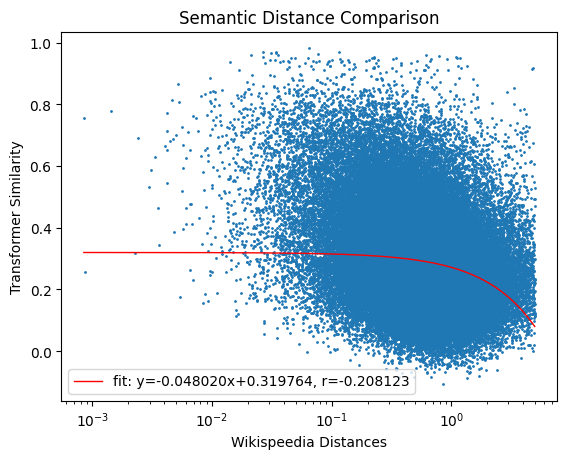

In [11]:
plt.scatter(wikispeedia_dists, transformer_dists, s=1)
plt.xlabel('Wikispeedia Distances')
plt.ylabel('Transformer Similarity')
plt.title('Semantic Distance Comparison')
plt.xscale('log')

# plot regression line (avoid log(0) by starting from the smallest positive x)
xmin = x[x > 0].min()
xmax = x.max()
xs = np.logspace(np.log10(xmin), np.log10(xmax), 200)
ys = slope * xs + intercept
plt.plot(xs, ys, color='red', linewidth=1, label=f'fit: y={slope:.6f}x+{intercept:.6f}, r={r_value:.6f}')
plt.legend()
plt.show()

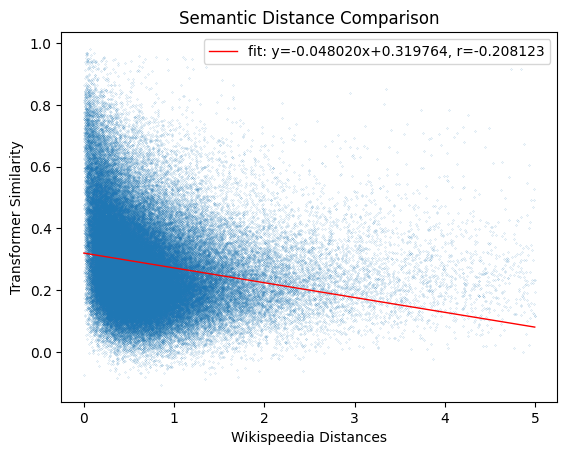

In [15]:
plt.scatter(wikispeedia_dists, transformer_dists, s=.01)
plt.xlabel('Wikispeedia Distances')
plt.ylabel('Transformer Similarity')
plt.title('Semantic Distance Comparison')

# plot regression line across the data range
xmin = x.min()
xmax = x.max()
xs = np.linspace(xmin, xmax, 200)
ys = slope * xs + intercept
plt.plot(xs, ys, color='red', linewidth=1, label=f'fit: y={slope:.6f}x+{intercept:.6f}, r={r_value:.6f}')
plt.legend()
plt.show()